## Customer Churn Prediction Analysis
**Dataset:** Orange Telecom Customer Churn Dataset (80/20 split)  
**Objective:** Identify at-risk customers and build a predictive model to support proactive retention.

---
#### Table of Contents
1. Data Loading from AWS S3  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering  
4. Customer Segmentation (K-Means)  
5. Predictive Modelling  
6. Model Evaluation  
7. Business Impact Analysis  


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import boto3

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', font_scale=1.05)
print("All imports successful")

All imports successful


#### 1. Data Loading from AWS S3

In [12]:
BUCKET = 'cw2-portfolio-orange-2026-comscds25.1'

def load_from_s3(key):
    s3  = boto3.client('s3')
    obj = s3.get_object(Bucket=BUCKET, Key=key)
    return pd.read_csv(obj['Body'])

train = load_from_s3('churn-bigml-80.csv')   
test  = load_from_s3('churn-bigml-20.csv')   

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"\nColumn dtypes:\n{train.dtypes}")
print(f"\nMissing values: {train.isnull().sum().sum()}")

Train shape : (2666, 20)
Test  shape : (667, 20)

Column dtypes:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Missing values: 0


In [13]:
train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [14]:
test.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


#### 2. Exploratory Data Analysis

In [15]:
# Class distribution
churn_counts = train['Churn'].value_counts()
print("Churn distribution (train):")
print(churn_counts)
print(f"\nChurn rate: {train['Churn'].mean()*100:.1f}%")

train.describe()

Churn distribution (train):
Churn
False    2278
True      388
Name: count, dtype: int64

Churn rate: 14.6%


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


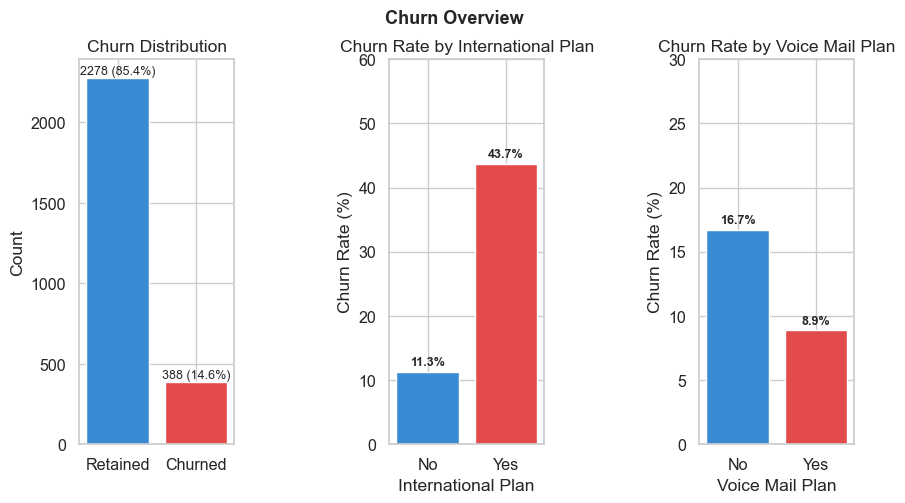

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle('Churn Overview', fontsize=13, fontweight='bold')

# Churn distribution 
churn_counts = train['Churn'].value_counts()
axes[0].bar(['Retained', 'Churned'], churn_counts.values,
            color=['#3B8BD4', '#E24B4A'], edgecolor='white')
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, f'{v} ({v/len(train)*100:.1f}%)',
                 ha='center', fontsize=9)

# Churn rate by International plan 
ip_churn = train.groupby('International plan')['Churn'].mean() * 100
bars = axes[1].bar(ip_churn.index, ip_churn.values,
                   color=['#3B8BD4', '#E24B4A'], edgecolor='white')
axes[1].set_title('Churn Rate by International Plan')
axes[1].set_xlabel('International Plan')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 60)
for bar, val in zip(bars, ip_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Churn rate by Voice mail plan 
vm_churn = train.groupby('Voice mail plan')['Churn'].mean() * 100
bars = axes[2].bar(vm_churn.index, vm_churn.values,
                   color=['#3B8BD4', '#E24B4A'], edgecolor='white')
axes[2].set_title('Churn Rate by Voice Mail Plan')
axes[2].set_xlabel('Voice Mail Plan')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_ylim(0, 30)
for bar, val in zip(bars, vm_churn.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.subplots_adjust(wspace=1)
plt.show()

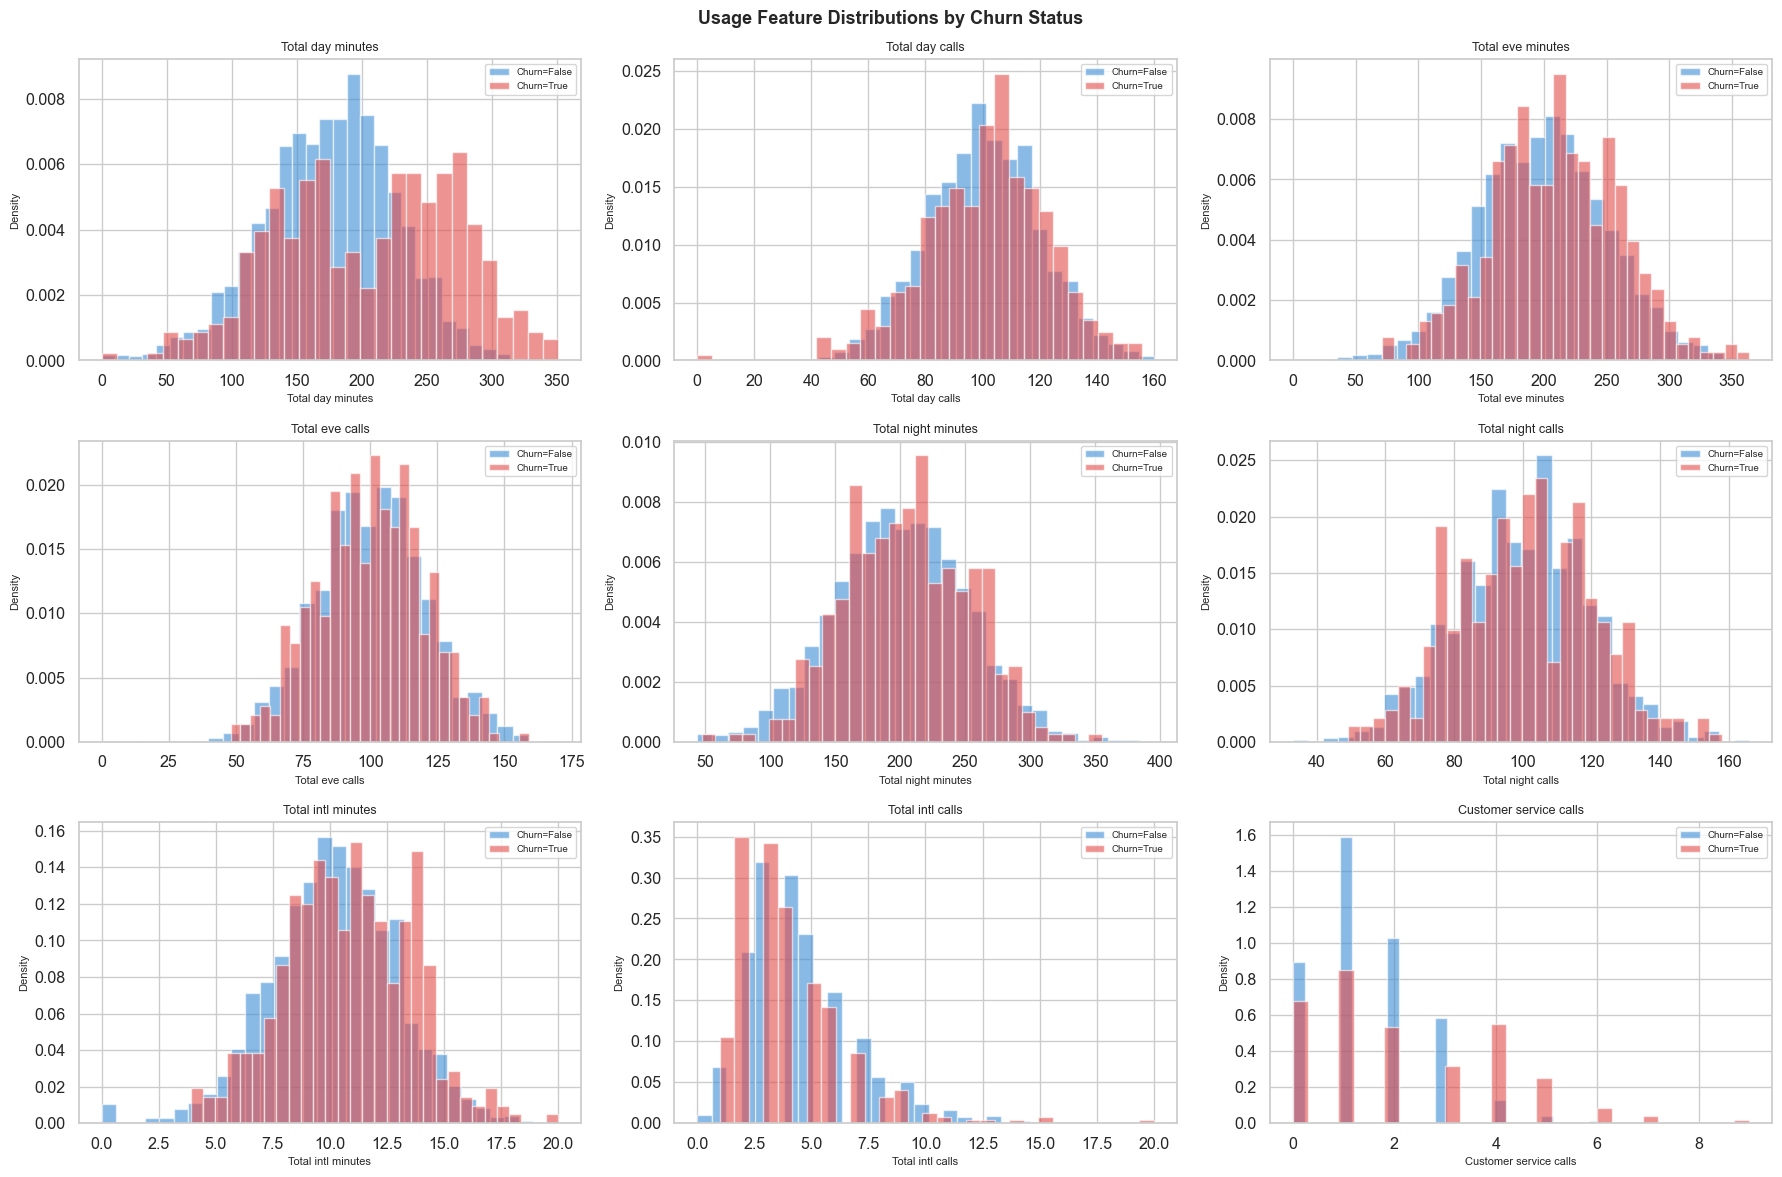

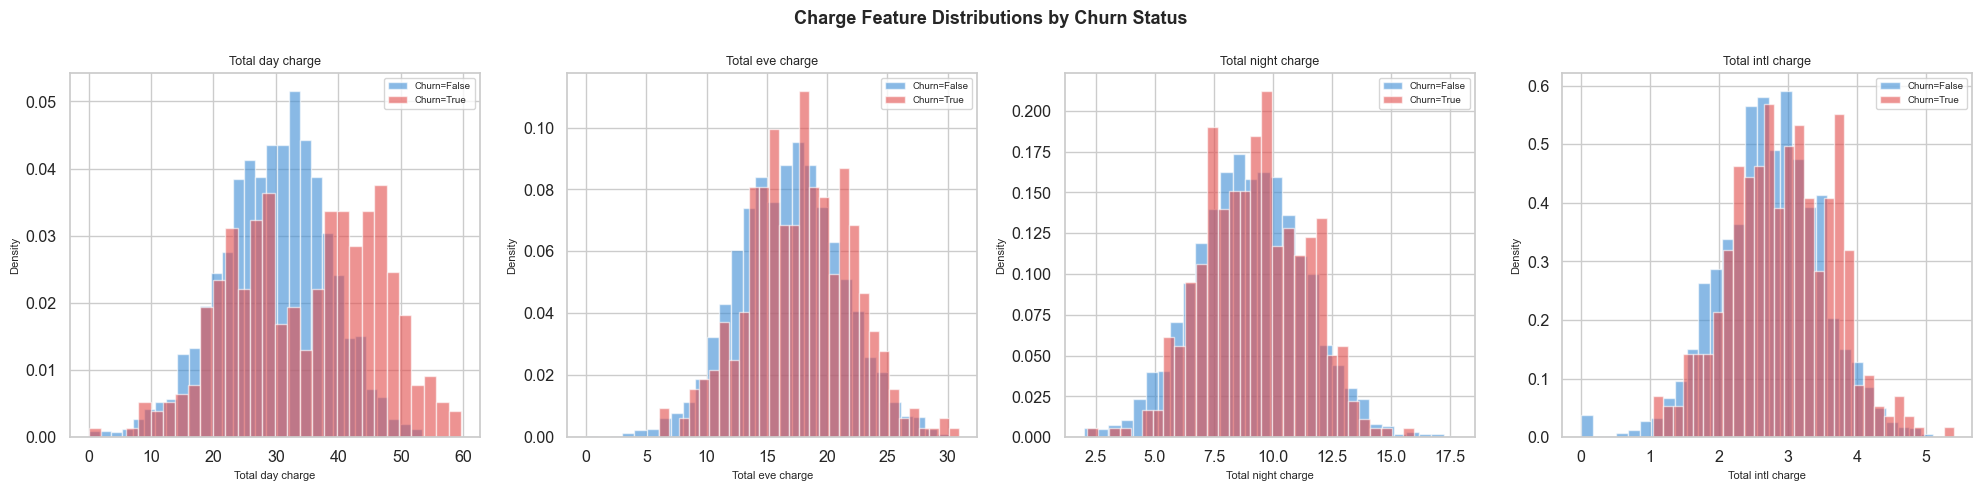

In [17]:
# Feature distributions by churn status
usage_features = [
    'Total day minutes',   'Total day calls',
    'Total eve minutes',   'Total eve calls',
    'Total night minutes', 'Total night calls',
    'Total intl minutes',  'Total intl calls',
    'Customer service calls'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Usage Feature Distributions by Churn Status', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), usage_features):
    for val, color in [('False', '#3B8BD4'), ('True', '#E24B4A')]:
        sub = train[train['Churn'].astype(str) == val][col]
        ax.hist(sub, bins=30, alpha=0.6, color=color, label=f'Churn={val}', density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

charge_features = [
    'Total day charge',
    'Total eve charge',
    'Total night charge',
    'Total intl charge'
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Charge Feature Distributions by Churn Status', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), charge_features):
    for val, color in [('False', '#3B8BD4'), ('True', '#E24B4A')]:
        sub = train[train['Churn'].astype(str) == val][col]
        ax.hist(sub, bins=30, alpha=0.6, color=color, label=f'Churn={val}', density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

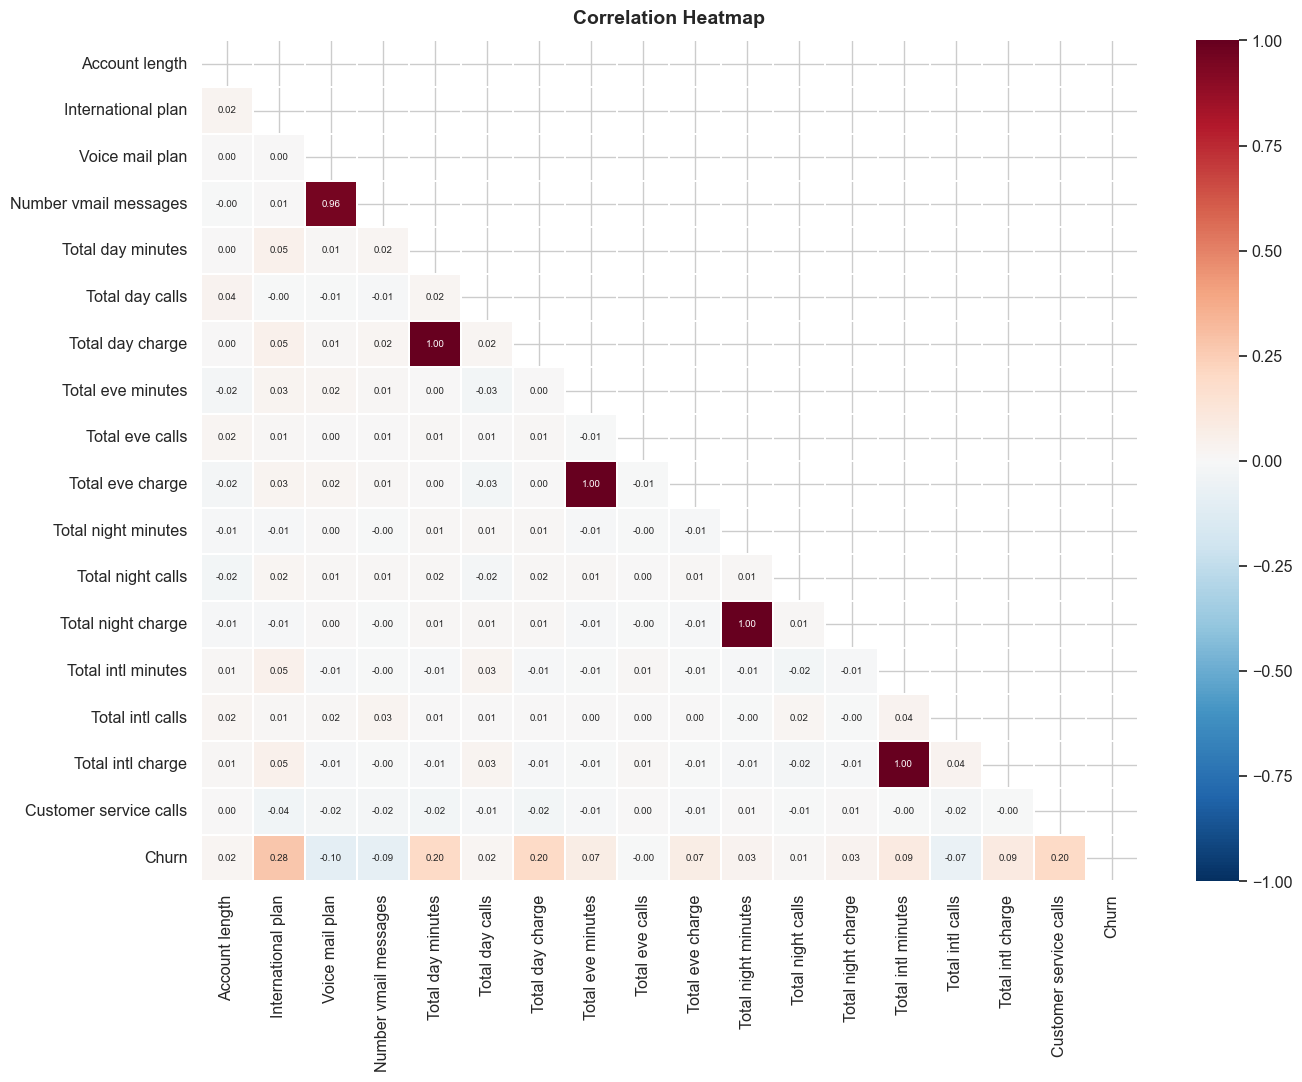

In [18]:
# Correlation heatmap
df_corr = train.copy()
df_corr['Churn']              = df_corr['Churn'].astype(int)
df_corr['International plan'] = LabelEncoder().fit_transform(df_corr['International plan'])
df_corr['Voice mail plan']    = LabelEncoder().fit_transform(df_corr['Voice mail plan'])
df_corr.drop(columns=['State','Area code'], inplace=True)

corr = df_corr.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={'size':7})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

#### 3. Feature Engineering & Preprocessing

In [19]:
def preprocess(df, le_dict=None, fit=True):
    """Encode, drop non-predictive columns, and engineer new features."""
    df = df.copy()
    df.drop(columns=[c for c in ['State','Area code'] if c in df.columns], inplace=True)
    df['Churn'] = df['Churn'].astype(int)

    for col in ['International plan','Voice mail plan']:
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            if le_dict is not None: le_dict[col] = le
        else:
            df[col] = le_dict[col].transform(df[col])


    df['Total minutes'] = df[['Total day minutes','Total eve minutes',
                               'Total night minutes','Total intl minutes']].sum(axis=1)
    df['Total charges'] = df[['Total day charge','Total eve charge',
                               'Total night charge','Total intl charge']].sum(axis=1)
    df['Day usage pct'] = df['Total day minutes'] / (df['Total minutes'] + 1e-9)
    df['CS call flag']  = (df['Customer service calls'] >= 4).astype(int)
    return df

le_dict  = {}
train_p  = preprocess(train.copy(), le_dict, fit=True)
test_p   = preprocess(test.copy(),  le_dict, fit=False)

X_train, y_train = train_p.drop(columns=['Churn']), train_p['Churn']
X_test,  y_test  = test_p.drop(columns=['Churn']),  test_p['Churn']

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {list(X_train.columns)}")

X_train: (2666, 21)  |  X_test: (667, 21)
Features: ['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Total minutes', 'Total charges', 'Day usage pct', 'CS call flag']


#### 4. Customer Segmentation (K-Means Clustering)

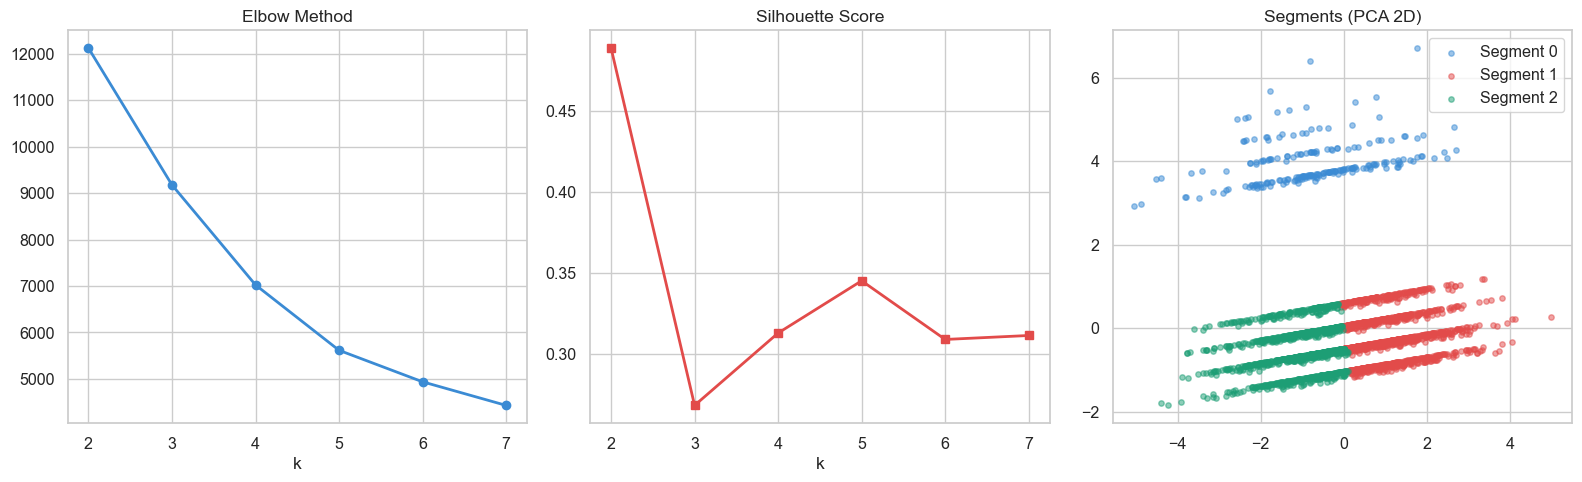


 Segment Profiles 
         Total minutes  Total charges  Customer service calls  \
Segment                                                         
0              587.287         58.807                   4.576   
1              658.619         67.237                   1.270   
2              519.395         50.975                   1.343   

         International plan  Number vmail messages  CS call flag  Churn  
Segment                                                                  
0                     0.105                  7.638           1.0  0.529  
1                     0.117                  8.294           0.0  0.170  
2                     0.084                  7.796           0.0  0.051  


In [25]:
seg_features = ['Total minutes','Total charges','Customer service calls',
                'International plan','Number vmail messages','CS call flag']
X_seg = StandardScaler().fit_transform(X_train[seg_features])


inertias, sils = [], []
for k in range(2, 8):
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_seg)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_seg, labs))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(range(2,8), inertias, 'o-', color='#3B8BD4', linewidth=2)
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k')
axes[1].plot(range(2,8), sils, 's-', color='#E24B4A', linewidth=2)
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')


km3         = KMeans(n_clusters=3, random_state=42, n_init=10)
seg_labels  = km3.fit_predict(X_seg)
X_pca       = PCA(n_components=2, random_state=42).fit_transform(X_seg)
for i, c in enumerate(['#3B8BD4','#E24B4A','#1D9E75']):
    m = seg_labels == i
    axes[2].scatter(X_pca[m,0], X_pca[m,1], c=c, alpha=0.5, s=15, label=f'Segment {i}')
axes[2].set_title('Segments (PCA 2D)'); axes[2].legend()
plt.tight_layout()
plt.show()

# Segment profiles
train_p['Segment'] = seg_labels
print("\n Segment Profiles ")
print(train_p.groupby('Segment')[seg_features+['Churn']].mean().round(3))

#### 5. Predictive Modelling

In [26]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                   max_depth=12, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                       learning_rate=0.08, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
print("5-Fold Cross-Validation (ROC-AUC):")
for name, model in models.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='roc_auc')
    results[name] = {'cv_mean': scores.mean(), 'cv_std': scores.std()}
    print(f"  {name:<25} AUC = {scores.mean():.4f} +/- {scores.std():.4f}")
    model.fit(X_train_s, y_train)

5-Fold Cross-Validation (ROC-AUC):
  Logistic Regression       AUC = 0.8728 +/- 0.0179
  Random Forest             AUC = 0.9240 +/- 0.0077
  Gradient Boosting         AUC = 0.9225 +/- 0.0094


#### 6. Model Evaluation

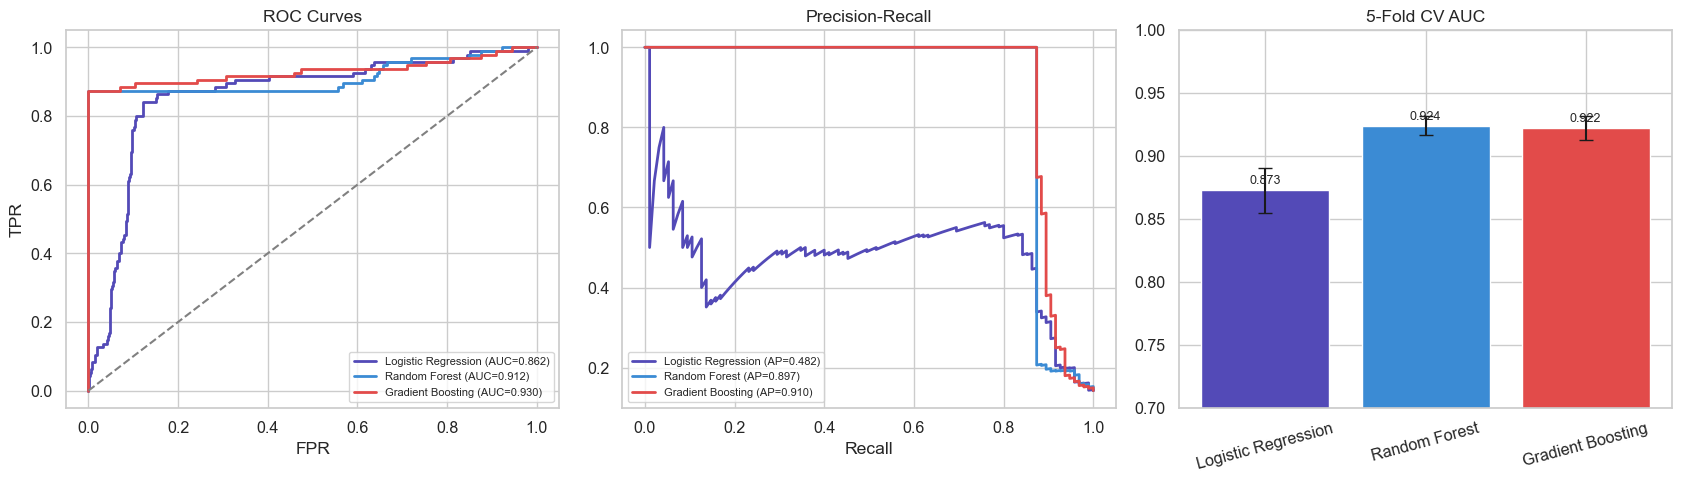

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_m = {'Logistic Regression':'#534AB7','Random Forest':'#3B8BD4','Gradient Boosting':'#E24B4A'}

for name, model in models.items():
    yp = model.predict_proba(X_test_s)[:,1]
    fpr,tpr,_ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    results[name]['auc'] = auc
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors_m[name], linewidth=2)
    prec,rec,_ = precision_recall_curve(y_test, yp)
    ap = average_precision_score(y_test, yp)
    results[name]['ap'] = ap
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=colors_m[name], linewidth=2)

axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].set_title('ROC Curves')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=8)
axes[1].set_title('Precision-Recall'); axes[1].set_xlabel('Recall'); axes[1].legend(fontsize=8)

names = list(results.keys())
bars = axes[2].bar(names, [results[n]['cv_mean'] for n in names],
                   yerr=[results[n]['cv_std'] for n in names], capsize=5,
                   color=[colors_m[n] for n in names], edgecolor='white')
axes[2].set_title('5-Fold CV AUC'); axes[2].set_ylim(0.7,1.0)
axes[2].tick_params(axis='x', rotation=15)
for bar, v in zip(bars,[results[n]['cv_mean'] for n in names]):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Best model: Gradient Boosting
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99       572
     Churned       1.00      0.87      0.93        95

    accuracy                           0.98       667
   macro avg       0.99      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667



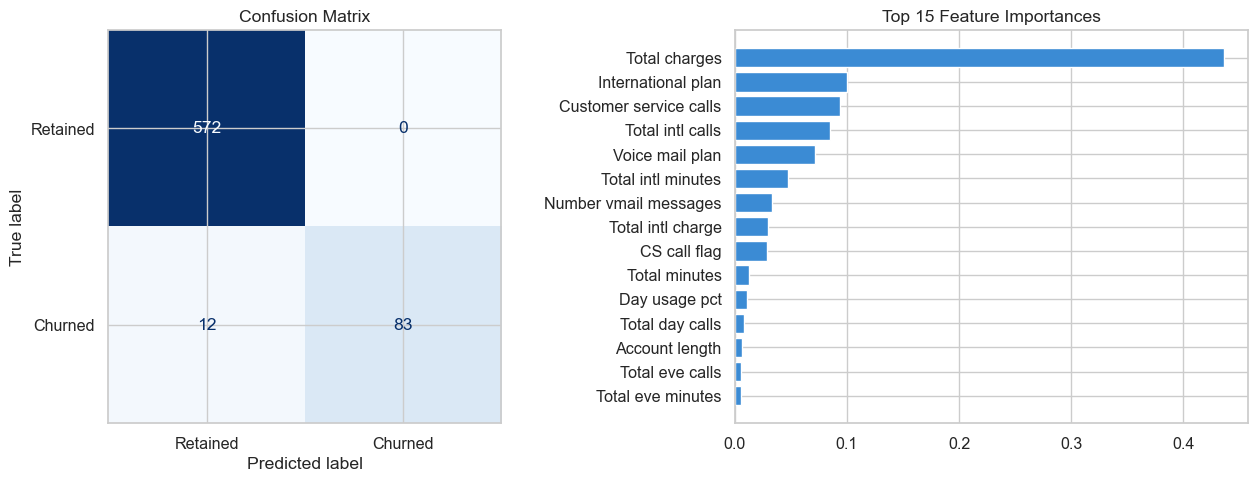

In [28]:
# Choosing best model
best_name  = max(results, key=lambda n: results[n]['auc'])
best_model = models[best_name]
y_pred     = best_model.predict(X_test_s)
y_prob     = best_model.predict_proba(X_test_s)[:,1]

print(f"Best model: {best_name}")
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Retained','Churned'], cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

imp_df = pd.DataFrame({'Feature':X_train.columns,
                       'Importance':best_model.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=True).tail(15)
axes[1].barh(imp_df['Feature'], imp_df['Importance'], color='#3B8BD4', edgecolor='white')
axes[1].set_title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

#### 7. Business Impact Analysis

TP=83  FP=0  TN=572  FN=12
Estimated net savings (per 667-customer cohort): $37,350
  Customers correctly flagged for retention: 83
  Churners missed (false negatives):         12
  Wasted retention offers:                   0


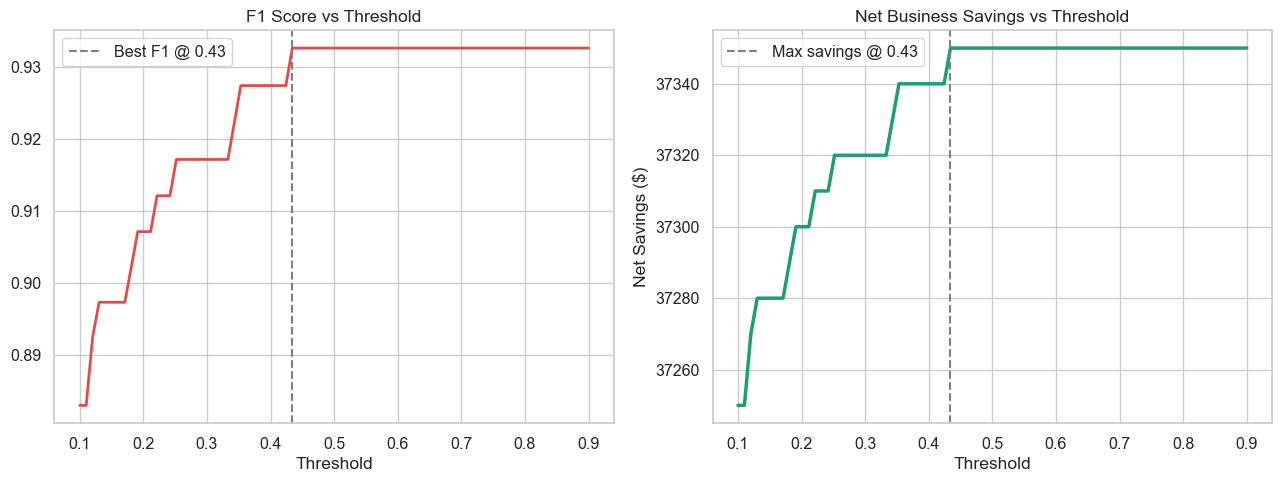

In [29]:
avg_ltv        = 500   #lifetime value per customer
retention_cost = 50    #cost of a retention offer
fp_cost        = 10    #wasted on false positives

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
net_savings = (tp * avg_ltv) - (tp * retention_cost) - (fp * fp_cost)

print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"Estimated net savings (per {len(y_test)}-customer cohort): ${net_savings:,.0f}")
print(f"  Customers correctly flagged for retention: {tp}")
print(f"  Churners missed (false negatives):         {fn}")
print(f"  Wasted retention offers:                   {fp}")

# Threshold sweep
thresholds = np.linspace(0.1, 0.9, 80)
f1s, savings_list = [], []
for t in thresholds:
    yp   = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test, yp)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    p  = tp_t / (tp_t + fp_t + 1e-9)
    r  = tp_t / (tp_t + fn_t + 1e-9)
    f1s.append(2*p*r / (p+r+1e-9))
    savings_list.append((tp_t*avg_ltv) - (tp_t*retention_cost) - (fp_t*fp_cost))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(thresholds, f1s, color='#E24B4A', linewidth=2)
axes[0].axvline(thresholds[np.argmax(f1s)], linestyle='--', color='gray',
                label=f"Best F1 @ {thresholds[np.argmax(f1s)]:.2f}")
axes[0].set_title('F1 Score vs Threshold'); axes[0].set_xlabel('Threshold')
axes[0].legend()
axes[1].plot(thresholds, savings_list, color='#1D9E75', linewidth=2.5)
axes[1].axvline(thresholds[np.argmax(savings_list)], linestyle='--', color='gray',
                label=f"Max savings @ {thresholds[np.argmax(savings_list)]:.2f}")
axes[1].set_title('Net Business Savings vs Threshold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Net Savings ($)')
axes[1].legend()
plt.tight_layout()
plt.show()